# Publication figures from completed carry-on benchmark tables

Run this notebook from the repository root, `results/`, or `results/tables/`. It reads the three completed comparison CSVs and produces the same publication figure file names as before, so Overleaf paths do not need to change.

This version also recognizes the provider-style answer metrics added to Comparison 01/02/03, including brand mention rate, citation share of voice, mention share of voice, and mention/citation position improvement. The main figure names are unchanged:

- `figure1_product_effect_heatmap`
- `figure2_observed_geo_alignment_scatter_single_column`
- `figure2_observed_geo_alignment_scatter_full_width`
- `figureS1_metric_delta_heatmaps_no_colorbar`
- `figureS2_geo_vs_current_bar`

The extra provider-style metrics are folded into Supplementary Figure S1 only when the corresponding columns exist in the input CSVs. Source/domain share is not plotted because the current carry-on answer files use controlled product-label citations, not external URL/domain citations.


In [31]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display, Image

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "font.family": "DejaVu Sans",
    "font.size": 7.5,
    "axes.titlesize": 8.0,
    "axes.labelsize": 7.5,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "legend.fontsize": 7.0,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def mm_to_inch(w, h):
    return (w / 25.4, h / 25.4)

PRODUCT_ORDER = ["Monos", "BÉIS", "Travelpro", "INUSA", "Delsey"]
N_PRODUCTS = len(PRODUCT_ORDER)
PRODUCT_ALIASES = {
    "monos": "Monos",
    "beis": "BÉIS",
    "béis": "BÉIS",
    "travel": "Travelpro",
    "tarvel": "Travelpro",
    "travelpro": "Travelpro",
    "inusa": "INUSA",
    "delsey": "Delsey",
}

FIGSIZE_HEATMAP_FULL = mm_to_inch(170, 62)
FIGSIZE_SCATTER_SINGLE = mm_to_inch(85, 68)
FIGSIZE_SCATTER_FULL = mm_to_inch(170, 72)
FIGSIZE_SUPP_FULL = mm_to_inch(170, 90)

In [32]:
def find_tables_dir(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = []
    for p in [start] + list(start.parents):
        candidates += [
            p,
            p / "results" / "tables",
            p / "code" / "data" / "results" / "tables",
            p / "data" / "results" / "tables",
        ]
    for base in [start, start.parent]:
        if base.exists():
            candidates += list(base.glob("**/results/tables"))
            candidates += list(base.glob("**/code/data/results/tables"))

    seen, unique = set(), []
    for c in candidates:
        try:
            c = c.resolve()
        except Exception:
            continue
        if c not in seen:
            seen.add(c)
            unique.append(c)

    for c in unique:
        if c.exists() and c.is_dir():
            if any(child.is_dir() and child.name.startswith(("01_", "02_", "03_")) for child in c.iterdir()):
                return c

    checked = "\n".join(str(c) for c in unique[:40])
    raise FileNotFoundError("Could not find results/tables. Checked:\n" + checked)

TABLES_DIR = find_tables_dir()
RESULTS_DIR = TABLES_DIR.parent
FIG_MAIN_DIR = RESULTS_DIR / "figures" / "main"
FIG_SUPP_DIR = RESULTS_DIR / "figures" / "supplementary"
FIG_TABLE_DIR = TABLES_DIR / "figure_outputs"
for d in [FIG_MAIN_DIR, FIG_SUPP_DIR, FIG_TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("TABLES_DIR:", TABLES_DIR)
print("FIG_MAIN_DIR:", FIG_MAIN_DIR)
print("FIG_SUPP_DIR:", FIG_SUPP_DIR)

TABLES_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\tables
FIG_MAIN_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main
FIG_SUPP_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary


In [33]:
def find_csv(folder_prefix, file_name):
    matches = sorted(TABLES_DIR.glob(f"{folder_prefix}*/{file_name}"))
    if not matches:
        matches = [p for p in sorted(TABLES_DIR.glob(f"**/{file_name}")) if p.parent.name.startswith(folder_prefix)]
    if not matches:
        available = "\n".join(str(p.relative_to(TABLES_DIR)) for p in sorted(TABLES_DIR.glob("**/*.csv"))[:100])
        raise FileNotFoundError(f"Missing {file_name} under {folder_prefix}*. Available CSVs:\n{available}")
    return matches[0]

PATH_01 = find_csv("01_", "current_vs_baseline_delta_by_product.csv")
PATH_02 = find_csv("02_", "geo_vs_baseline_delta_by_product.csv")
PATH_03 = find_csv("03_", "geo_vs_current_delta_by_product.csv")

comp01 = pd.read_csv(PATH_01)
comp02 = pd.read_csv(PATH_02)
comp03 = pd.read_csv(PATH_03)

print("01:", PATH_01.relative_to(TABLES_DIR))
print("02:", PATH_02.relative_to(TABLES_DIR))
print("03:", PATH_03.relative_to(TABLES_DIR))
print("Shapes:", comp01.shape, comp02.shape, comp03.shape)

01: 01_2023_2024_original_vs_2026_current_baseline_based\current_vs_baseline_delta_by_product.csv
02: 02_2023_2024_original_vs_2023_2024_geo_rewrite_baseline_based\geo_vs_baseline_delta_by_product.csv
03: 03_2026_current_vs_2023_2024_geo_rewrite_baseline_current_chunked_based\geo_vs_current_delta_by_product.csv
Shapes: (5, 57) (5, 57) (5, 57)


In [34]:
def normalize_product(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    lower = s.lower()
    first = lower.replace("_", " ").replace("-", " ").split()[0]
    if first in PRODUCT_ALIASES:
        return PRODUCT_ALIASES[first]
    for alias, canonical in PRODUCT_ALIASES.items():
        if alias in lower:
            return canonical
    return s


def infer_product_col(df):
    for c in ["product", "Product", "product_label", "label", "brand", "Brand"]:
        if c in df.columns:
            return c
    best_col, best_score = None, -1
    for c in df.columns:
        vals = df[c].astype(str).str.lower().head(50)
        score = sum(any(alias in v for alias in PRODUCT_ALIASES) for v in vals)
        if score > best_score:
            best_col, best_score = c, score
    if best_score <= 0:
        raise ValueError(f"Could not infer product column: {list(df.columns)}")
    return best_col


def infer_advantage_col(df, keywords):
    for c in df.columns:
        lc = c.lower()
        if "advantage" in lc and all(k in lc for k in keywords):
            return c
    candidates = [c for c in df.columns if "advantage" in c.lower() and pd.api.types.is_numeric_dtype(df[c])]
    if len(candidates) == 1:
        return candidates[0]
    raise ValueError(f"Could not infer advantage column for {keywords}. Columns: {list(df.columns)}")


def product_advantage(df, keywords, out_col):
    pcol = infer_product_col(df)
    vcol = infer_advantage_col(df, keywords)
    out = df[[pcol, vcol]].copy()
    out.columns = ["product", out_col]
    out["product"] = out["product"].map(normalize_product)
    out[out_col] = pd.to_numeric(out[out_col], errors="coerce")
    return out.dropna().groupby("product", as_index=False)[out_col].mean()

summary = product_advantage(comp01, ["current"], "current_over_old")
summary = summary.merge(product_advantage(comp02, ["geo"], "geo_over_old"), on="product", how="outer")
summary = summary.merge(product_advantage(comp03, ["geo", "current"], "geo_over_current"), on="product", how="outer")
summary["order"] = summary["product"].map({p:i for i,p in enumerate(PRODUCT_ORDER)}).fillna(999)
summary = summary.sort_values(["order", "product"]).drop(columns="order").reset_index(drop=True)
summary["current_minus_geo_old_effect"] = summary["current_over_old"] - summary["geo_over_old"]
summary["same_direction_old_baseline"] = np.sign(summary["current_over_old"]) == np.sign(summary["geo_over_old"])
summary.to_csv(FIG_TABLE_DIR / "figure_product_level_summary.csv", index=False)
display(summary)

,product,current_over_old,geo_over_old,geo_over_current,current_minus_geo_old_effect,same_direction_old_baseline
0,Monos,0.212912,0.075915,-0.213358,0.136997,True
1,BÉIS,0.077565,0.007779,-0.000677,0.069785,True
2,Travelpro,0.064281,0.050848,0.021177,0.013432,True
3,INUSA,0.019176,0.010693,-0.038033,0.008483,True
4,Delsey,-0.079013,-0.109062,0.011036,0.030050,True


In [35]:
# Quick check: provider-style answer metrics from updated Comparison 01/02/03
# This prints what is available without saving any extra figure/table files.

PROVIDER_STYLE_CANDIDATE_COLUMNS = [
    "delta_brand_mention_rate",
    "delta_citation_share_of_voice",
    "delta_mention_share_of_voice",
    "delta_first_mention_score",
    "delta_brand_context_sentiment_score",
    "provider_style_visibility_delta",
    "historical_visibility_delta",
    "replacement_visibility_delta",
    "mention_position_improvement_current_minus_baseline",
    "citation_position_improvement_current_minus_baseline",
    "mention_position_improvement_geo_minus_baseline",
    "citation_position_improvement_geo_minus_baseline",
    "mention_position_improvement_geo_minus_current",
    "citation_position_improvement_geo_minus_current",
]

def available_provider_cols(df):
    return [c for c in PROVIDER_STYLE_CANDIDATE_COLUMNS if c in df.columns]

provider_col_report = pd.DataFrame({
    "comparison": ["01 current vs old", "02 GEO vs old", "03 GEO vs current"],
    "available_provider_columns": [
        ", ".join(available_provider_cols(comp01)) or "none found",
        ", ".join(available_provider_cols(comp02)) or "none found",
        ", ".join(available_provider_cols(comp03)) or "none found",
    ],
})
print("Provider-style metric columns found in input CSVs:")
display(provider_col_report)

print("Note: source/domain share is intentionally not expected here because the answer prompt uses product-label citations, not external URL/domain citations.")


Provider-style metric columns found in input CSVs:


,comparison,available_provider_columns
0,01 current vs old,"delta_brand_mention_rate, delta_citation_share..."
1,02 GEO vs old,"delta_brand_mention_rate, delta_citation_share..."
2,03 GEO vs current,"delta_brand_mention_rate, delta_citation_share..."


Note: source/domain share is intentionally not expected here because the answer prompt uses product-label citations, not external URL/domain citations.


In [36]:
def save_pdf_png(fig, out_base, show=True):
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    pdf_path = out_base.with_suffix(".pdf")
    png_path = out_base.with_suffix(".png")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white", transparent=False)
    fig.savefig(png_path, bbox_inches="tight", facecolor="white", transparent=False, dpi=350)
    plt.close(fig)
    print("Saved:", pdf_path)
    print("Saved:", png_path)
    if show:
        display(Image(filename=str(png_path)))


def annotation_color(value, cmap, norm, threshold=0.55):
    r, g, b, _ = cmap(norm(value))
    luminance = 0.2126*r + 0.7152*g + 0.0722*b
    return "white" if luminance < threshold else "black"

## Main Figure 1 — Product-level one-product replacement effects

This is the primary result figure. Each cell is an advantage-score difference from a one-product replacement run. Positive values mean that the replacement condition produced stronger benchmark answer behavior than its baseline condition.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure1_product_effect_heatmap.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure1_product_effect_heatmap.png


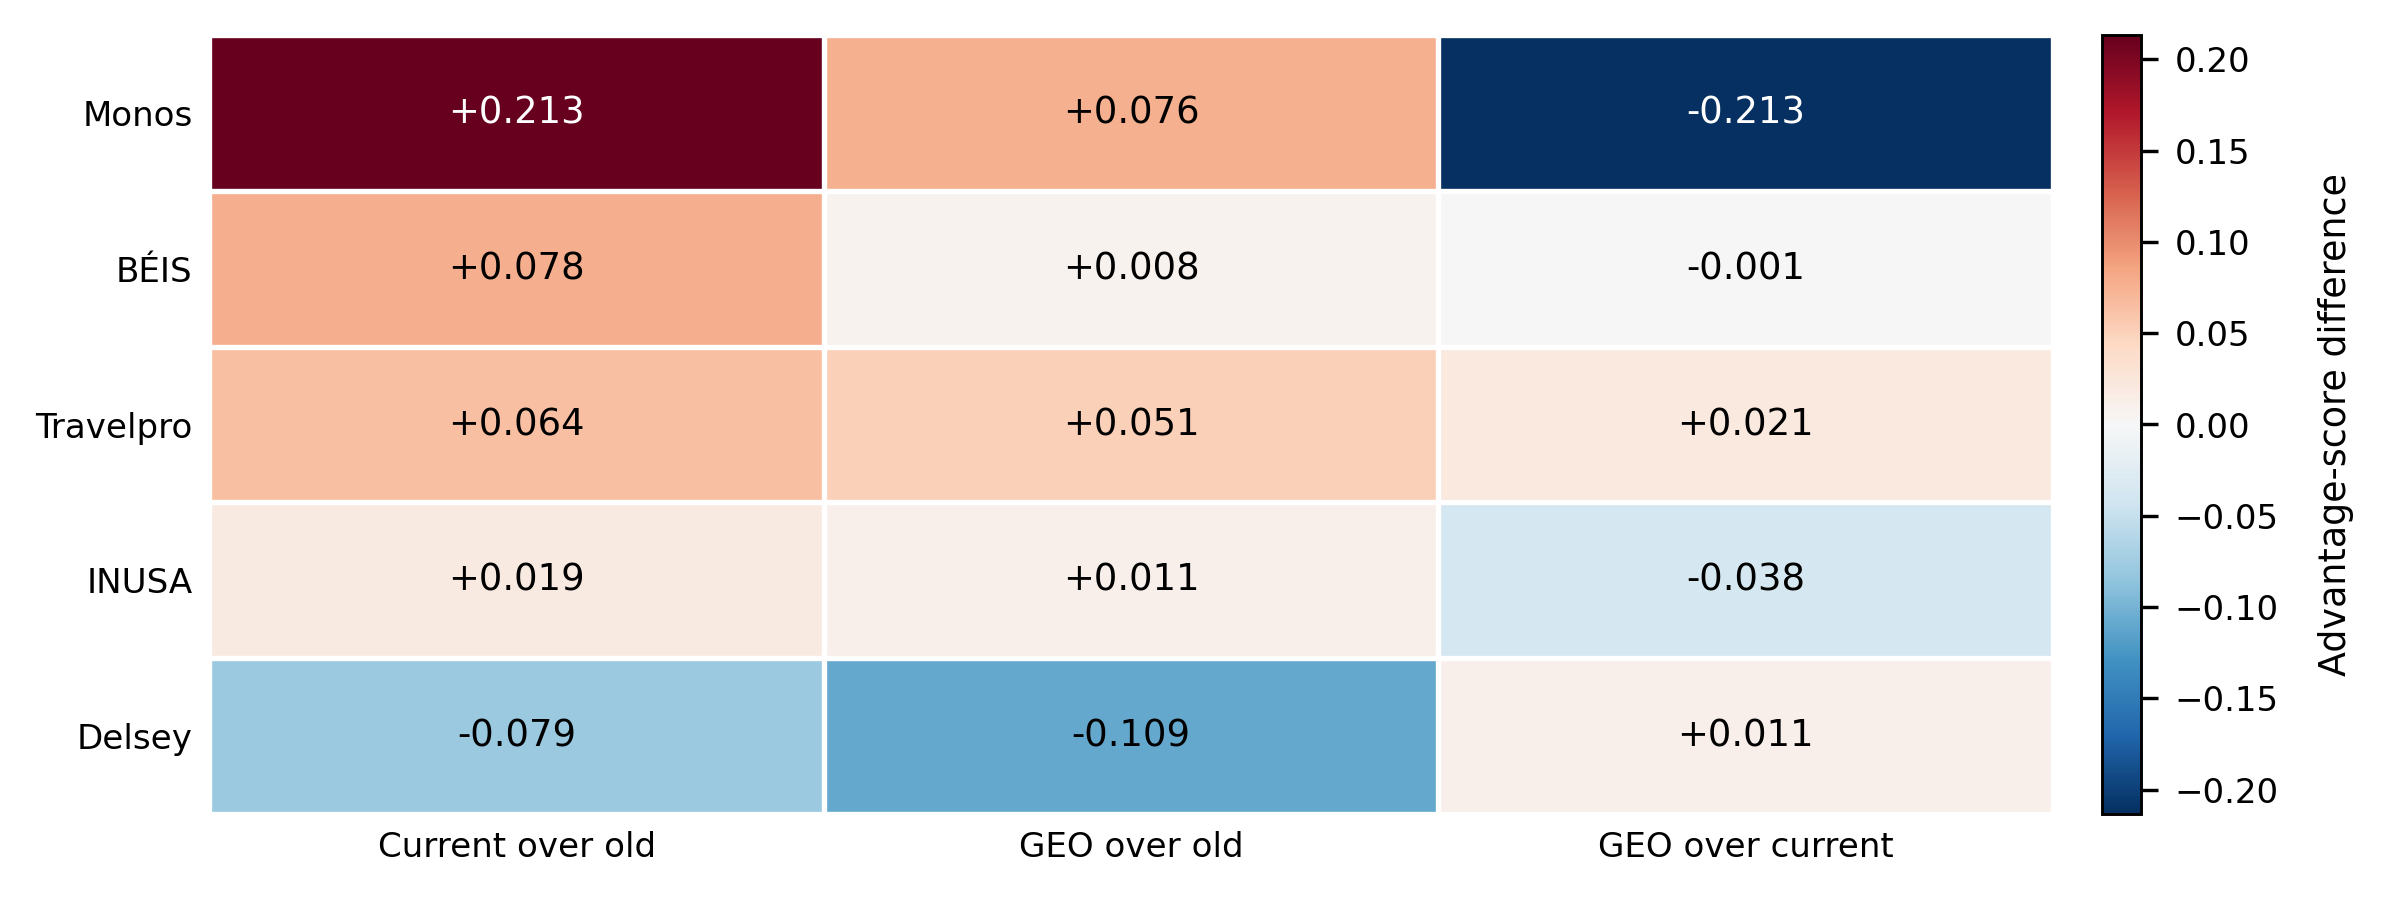

In [37]:
heatmap_cols = ["current_over_old", "geo_over_old", "geo_over_current"]
heatmap_labels = [
    "Current over old",
    "GEO over old",
    "GEO over current",
]
plot_df = summary.set_index("product").reindex(PRODUCT_ORDER)[heatmap_cols]
values = plot_df.to_numpy(dtype=float)

max_abs = np.nanmax(np.abs(values))
if not np.isfinite(max_abs) or max_abs == 0:
    max_abs = 0.1
vlim = max(0.05, max_abs)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP_FULL)
cmap = plt.get_cmap("RdBu_r")
norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
im = ax.imshow(values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_cols)))
ax.set_xticklabels(heatmap_labels)
ax.set_yticks(np.arange(len(PRODUCT_ORDER)))
ax.set_yticklabels(PRODUCT_ORDER)
ax.tick_params(axis="both", length=0)

ax.set_xticks(np.arange(-0.5, len(heatmap_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(PRODUCT_ORDER), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.1)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=7.6, color=annotation_color(val, cmap, norm))

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label("Advantage-score difference", labelpad=8)
cbar.outline.set_linewidth(0.6)

fig.tight_layout(pad=0.35)
save_pdf_png(fig, FIG_MAIN_DIR / "figure1_product_effect_heatmap")

## Main Figure 2 — Observed-vs-hypothetical GEO alignment scatter

Each point is one product. The x-axis is the one-product GEO-style rewrite effect relative to the all-old baseline. The y-axis is the one-product 2026 current-page effect relative to the same all-old baseline. This is the main alignment figure: it asks whether observed 2026 movement points in the same direction as the controlled GEO-style rewrite movement.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_single_column.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_single_column.png


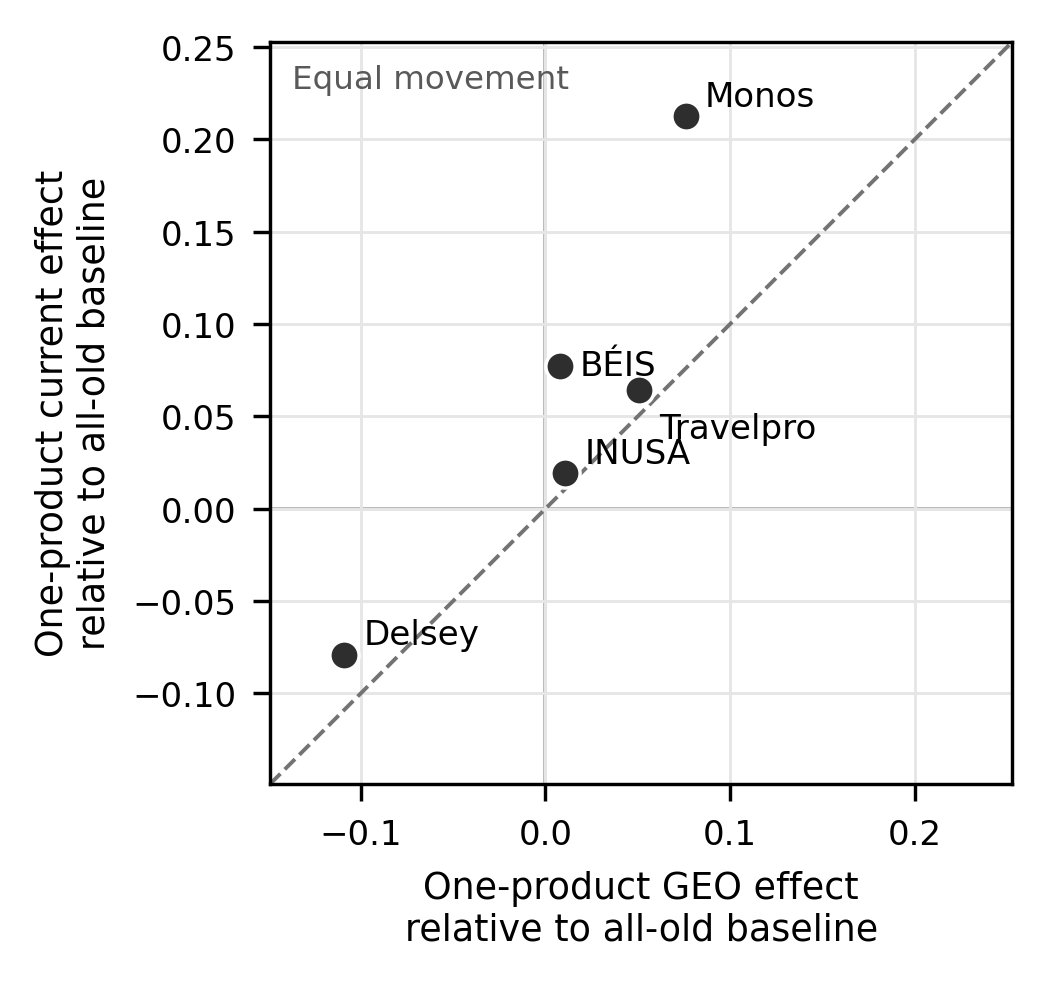

Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_full_width.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_full_width.png


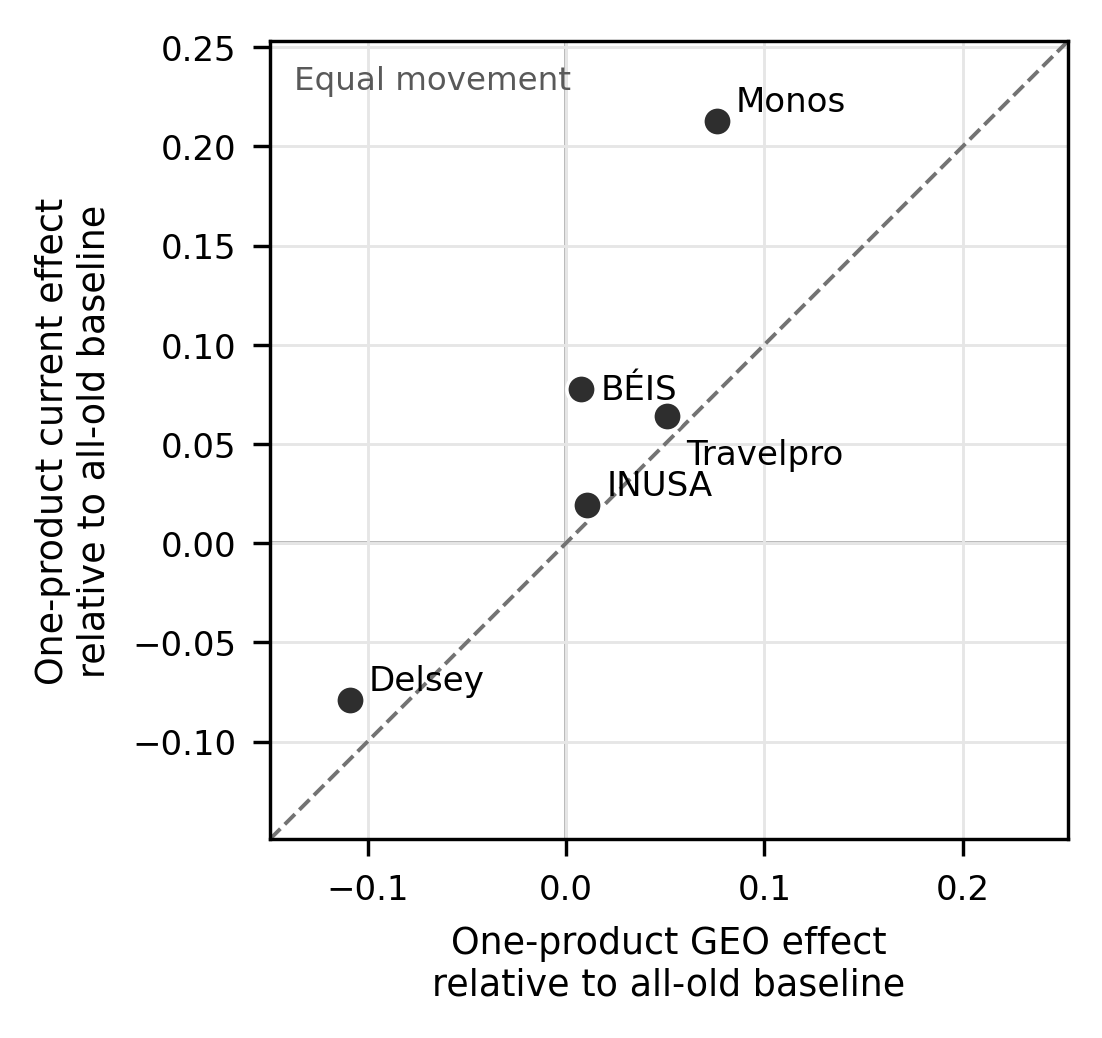

In [38]:
def make_alignment_scatter(figsize, out_name):
    df = summary.dropna(subset=["geo_over_old", "current_over_old"]).copy()
    x = df["geo_over_old"].to_numpy(float)
    y = df["current_over_old"].to_numpy(float)
    finite = np.concatenate([x[np.isfinite(x)], y[np.isfinite(y)]])
    lo = min(float(finite.min()) - 0.04, -0.02)
    hi = max(float(finite.max()) + 0.04, 0.02)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="0.72", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.72", linewidth=0.8, zorder=0)
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=0.8, color="0.45", zorder=1)
    ax.scatter(x, y, s=36, facecolor="0.18", edgecolor="white", linewidth=0.7, zorder=3)

    offsets = {"Monos": (4, 4), "BÉIS": (4, 0), "Travelpro": (4, -8), "INUSA": (4, 4), "Delsey": (4, 4)}
    for _, row in df.iterrows():
        dx, dy = offsets.get(row["product"], (4, 4))
        ax.annotate(row["product"], xy=(row["geo_over_old"], row["current_over_old"]),
                    xytext=(dx, dy), textcoords="offset points", fontsize=7.0, ha="left", va="center")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("One-product GEO effect\nrelative to all-old baseline")
    ax.set_ylabel("One-product current effect\nrelative to all-old baseline")
    ax.text(0.03, 0.97, "Equal movement", transform=ax.transAxes, fontsize=6.7, ha="left", va="top", color="0.35")
    ax.grid(True, color="0.90", linewidth=0.6)
    ax.set_axisbelow(True)
    fig.tight_layout(pad=0.35)
    save_pdf_png(fig, FIG_MAIN_DIR / out_name)

make_alignment_scatter(FIGSIZE_SCATTER_SINGLE, "figure2_observed_geo_alignment_scatter_single_column")
make_alignment_scatter(FIGSIZE_SCATTER_FULL, "figure2_observed_geo_alignment_scatter_full_width")

## Supplementary Figure S1 — Metric-level one-product replacement effects

This decomposes the composite advantage score into metric components. It is intended as supplementary material. The colorbar is omitted because every cell is annotated numerically.


Figure S1 revised successfully.
ROW_STEP=2.6, GROUP_GAP=2.8, OFFSET_SPAN=±0.72, HEIGHT=190mm
Saved with unchanged filename: figureS1_metric_delta_heatmaps_no_colorbar
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS1_metric_delta_heatmaps_no_colorbar.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS1_metric_delta_heatmaps_no_colorbar.png


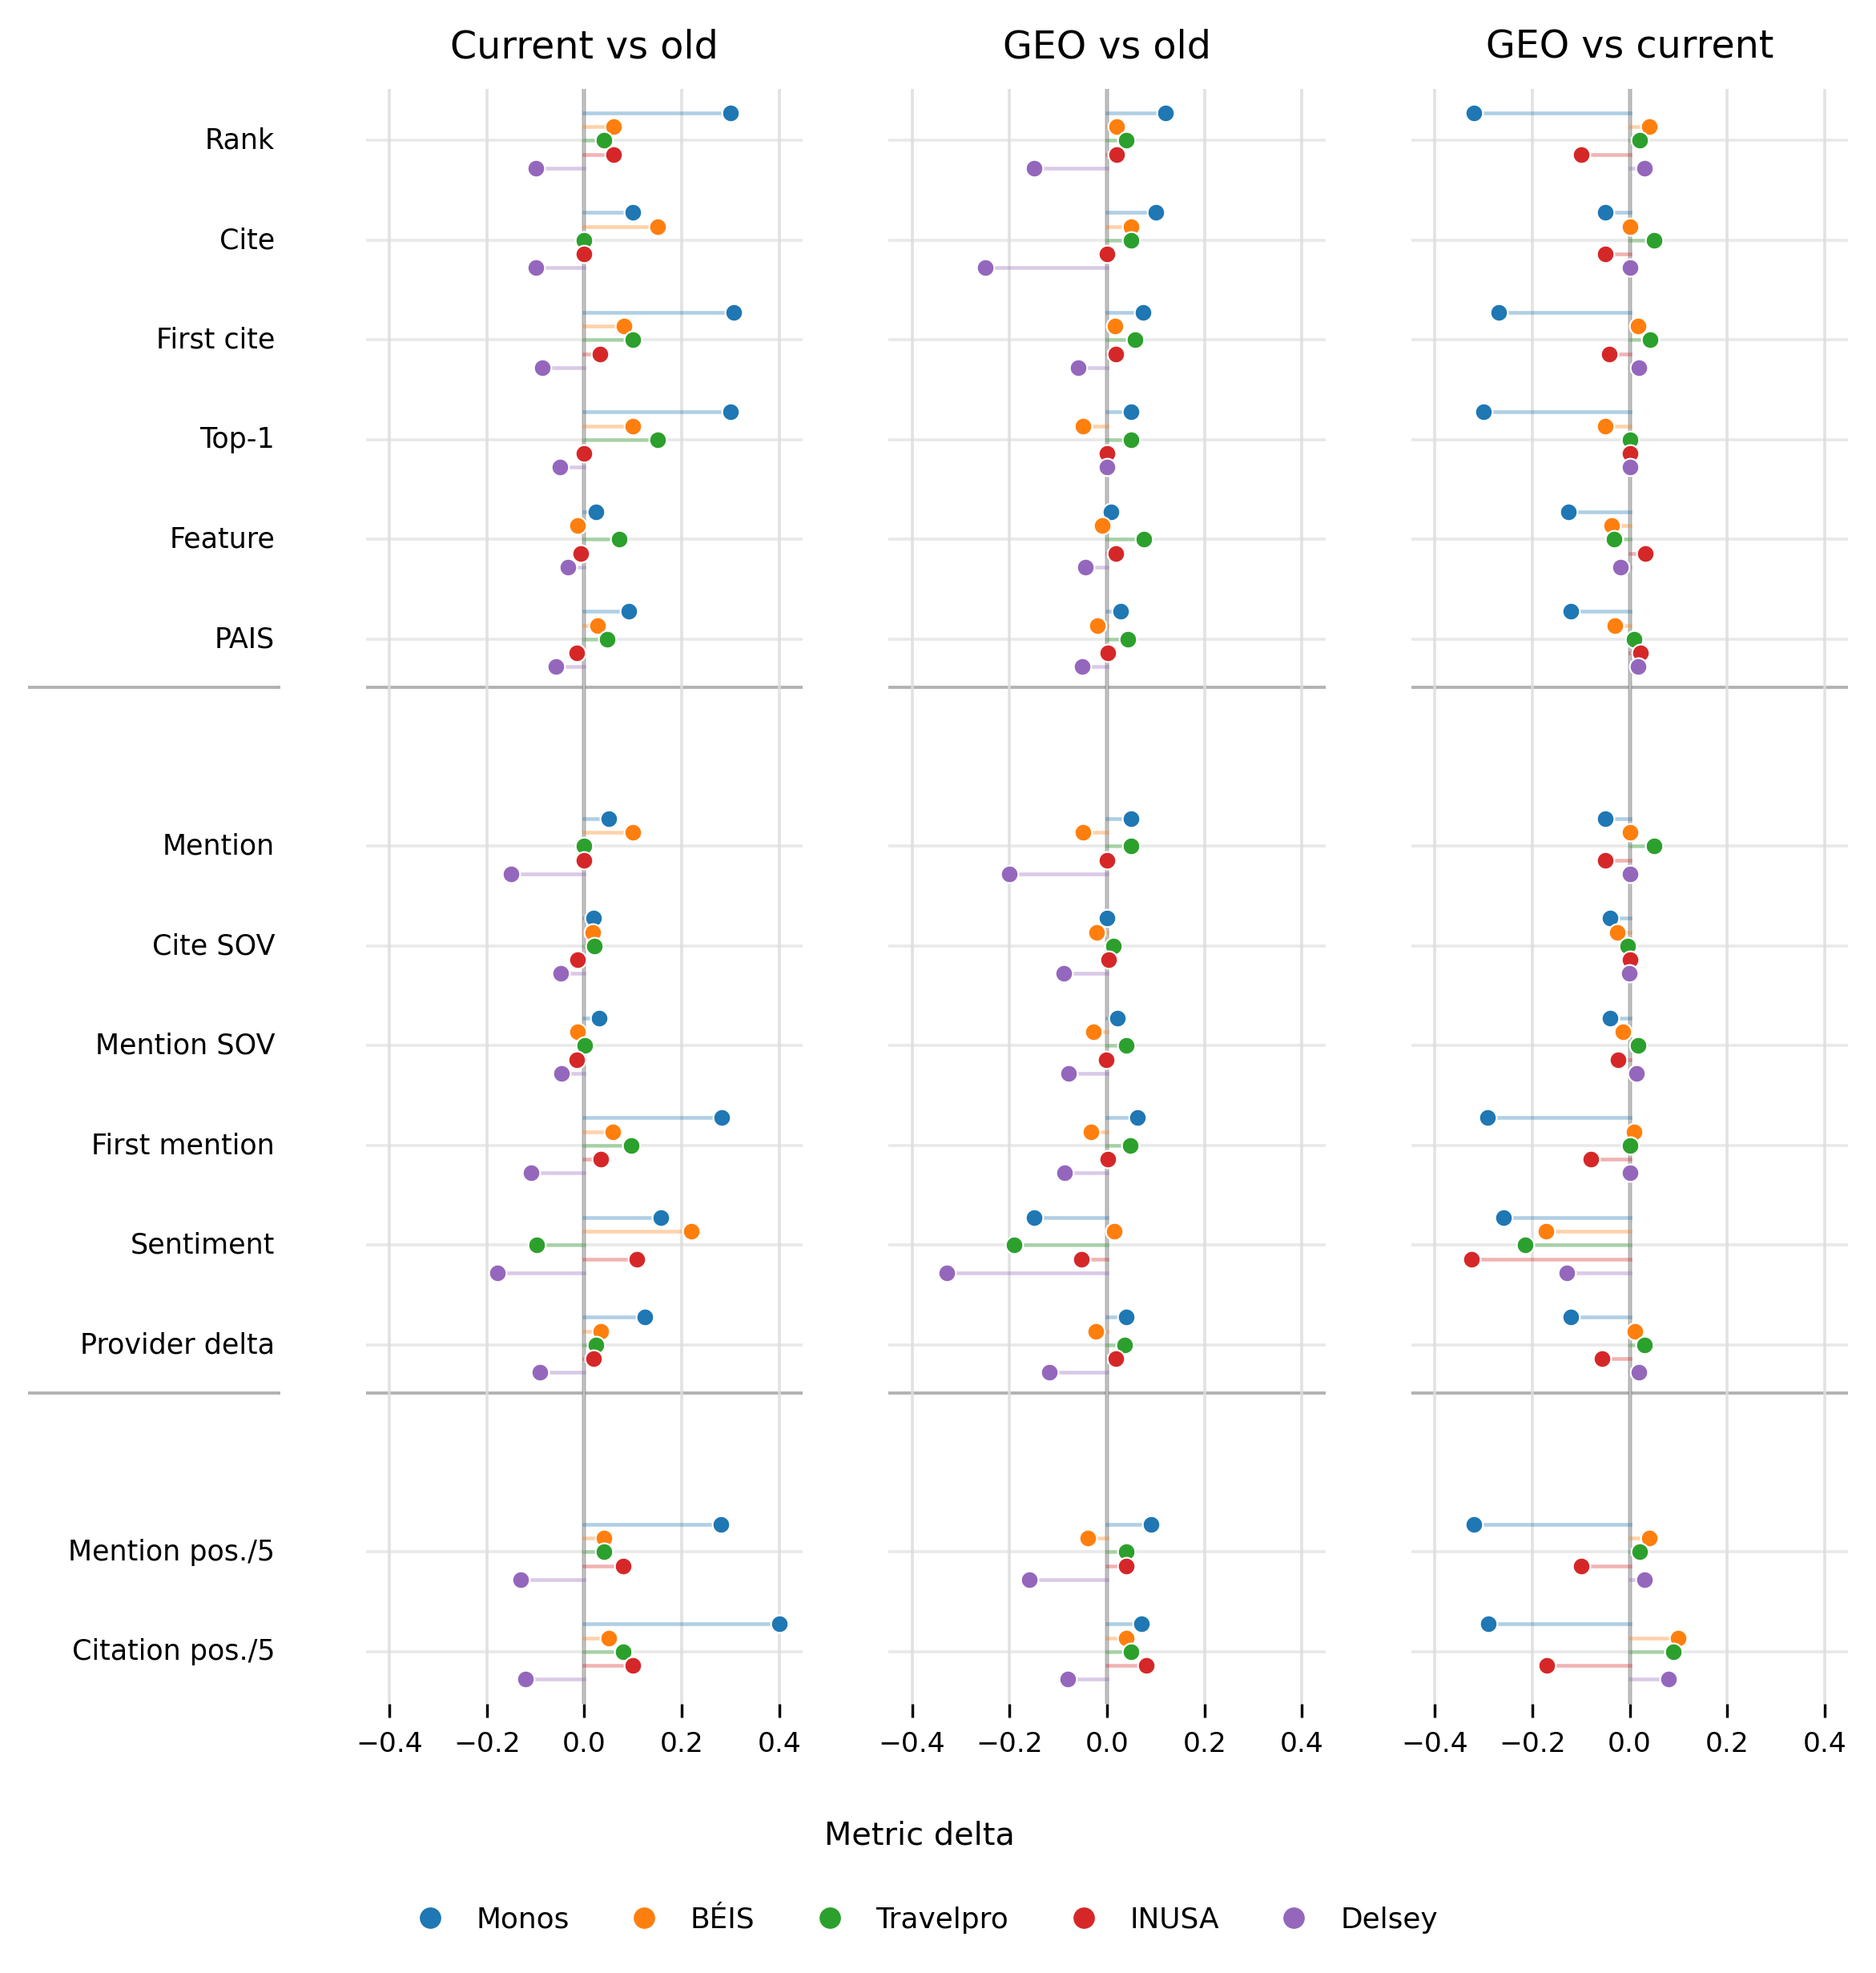

In [39]:
# ============================================================
# Supplementary Figure S1:
# Clean grouped metric-level decomposition using signed lollipop plots
# - metric rows strongly separated
# - product dots separated within each row
# - shared x label
# - group labels removed
# - bottom note removed
#
# Saved file name remains EXACTLY the same:
# figureS1_metric_delta_heatmaps_no_colorbar
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ------------------------------------------------------------
# 1. Metric definitions
# ------------------------------------------------------------
ORIGINAL_METRICS = [
    ("delta_rank_score_proxy", "Rank"),
    ("delta_citation_rate", "Cite"),
    ("delta_first_citation_score", "First cite"),
    ("delta_top1_cited_share", "Top-1"),
    ("delta_feature_coverage", "Feature"),
    ("delta_PAIS", "PAIS"),
    ("delta_pais", "PAIS"),
]

PROVIDER_METRICS = [
    ("delta_brand_mention_rate", "Mention"),
    ("delta_citation_share_of_voice", "Cite SOV"),
    ("delta_mention_share_of_voice", "Mention SOV"),
    ("delta_first_mention_score", "First mention"),
    ("delta_brand_context_sentiment_score", "Sentiment"),
    ("provider_style_visibility_delta", "Provider delta"),
]

POSITION_IMPROVEMENT_METRICS = [
    ("mention_position_improvement_current_minus_baseline", "Mention pos./5"),
    ("citation_position_improvement_current_minus_baseline", "Citation pos./5"),
    ("mention_position_improvement_geo_minus_baseline", "Mention pos./5"),
    ("citation_position_improvement_geo_minus_baseline", "Citation pos./5"),
    ("mention_position_improvement_geo_minus_current", "Mention pos./5"),
    ("citation_position_improvement_geo_minus_current", "Citation pos./5"),
]

METRIC_GROUPS = [
    ("Original", ORIGINAL_METRICS, 1.0),
    ("Provider", PROVIDER_METRICS, 1.0),
    ("Position", POSITION_IMPROVEMENT_METRICS, max(N_PRODUCTS, 1)),
]

COMPARISON_INPUTS = [
    (comp01, "Current vs old"),
    (comp02, "GEO vs old"),
    (comp03, "GEO vs current"),
]

COMPARISON_ORDER = ["Current vs old", "GEO vs old", "GEO vs current"]

# ------------------------------------------------------------
# 2. Visual spacing controls
# ------------------------------------------------------------
# These are intentionally large so each metric row is visibly separated.
ROW_STEP = 2.60
GROUP_GAP = 2.80
OFFSET_SPAN = 0.72
FIG_HEIGHT_MM = 190

DOT_SIZE = 20
LINE_WIDTH = 0.95
LINE_ALPHA = 0.35

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------
def _find_actual_col(df, wanted_col):
    if wanted_col in df.columns:
        return wanted_col
    lower = {c.lower(): c for c in df.columns}
    return lower.get(wanted_col.lower())

def _numeric_series_or_none(df, col):
    vals = pd.to_numeric(df[col], errors="coerce")
    if vals.notna().sum() == 0:
        return None
    return vals

def build_metric_long(df, comparison_title):
    pcol = infer_product_col(df)
    tmp = df.copy()
    tmp["product_norm"] = tmp[pcol].map(normalize_product)

    rows = []
    seen_metric_labels = set()

    for group_name, metric_list, scale in METRIC_GROUPS:
        for wanted_col, metric_label in metric_list:
            actual_col = _find_actual_col(tmp, wanted_col)
            if actual_col is None:
                continue

            vals = _numeric_series_or_none(tmp, actual_col)
            if vals is None:
                continue

            metric_key = (group_name, metric_label)
            if metric_key in seen_metric_labels:
                continue
            seen_metric_labels.add(metric_key)

            vals = vals / scale

            rows.append(pd.DataFrame({
                "comparison": comparison_title,
                "product_norm": tmp["product_norm"],
                "metric_group": group_name,
                "metric_label": metric_label,
                "value": vals,
            }))

    if not rows:
        return None

    out = pd.concat(rows, ignore_index=True)
    out = out.dropna(subset=["product_norm", "metric_label", "value"])
    out = out[out["product_norm"].isin(PRODUCT_ORDER)]
    return out

def save_same_name(fig):
    out_base = FIG_SUPP_DIR / "figureS1_metric_delta_heatmaps_no_colorbar"
    if "save_pdf_png" in globals():
        save_pdf_png(fig, out_base)
    else:
        out_base = Path(out_base)
        out_base.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(out_base) + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(str(out_base) + ".pdf", bbox_inches="tight")

# ------------------------------------------------------------
# 4. Build plotting dataframe
# ------------------------------------------------------------
plot_frames = []

for df, title in COMPARISON_INPUTS:
    long_df = build_metric_long(df, title)
    if long_df is not None and not long_df.empty:
        plot_frames.append(long_df)

if len(plot_frames) == 0:
    print("No metric-level delta columns found; skipping Figure S1.")

else:
    plot_df = pd.concat(plot_frames, ignore_index=True)

    metric_order_by_group = {
        "Original": [
            "Rank", "Cite", "First cite", "Top-1", "Feature", "PAIS",
        ],
        "Provider": [
            "Mention", "Cite SOV", "Mention SOV", "First mention", "Sentiment", "Provider delta",
        ],
        "Position": [
            "Mention pos./5", "Citation pos./5",
        ],
    }

    present_metrics = []
    metric_to_group = {}

    for group_name in ["Original", "Provider", "Position"]:
        for metric_label in metric_order_by_group[group_name]:
            if metric_label in set(plot_df["metric_label"]):
                present_metrics.append(metric_label)
                metric_to_group[metric_label] = group_name

    # ------------------------------------------------------------
    # 5. Vertical layout
    # ------------------------------------------------------------
    y_positions = {}
    y_ticks = []
    group_boundaries = []

    y = 0.0
    previous_group = None

    for metric_label in present_metrics:
        group_name = metric_to_group[metric_label]

        if previous_group is not None and group_name != previous_group:
            group_boundaries.append(y - ROW_STEP * 0.52)
            y += GROUP_GAP

        y_positions[metric_label] = y
        y_ticks.append(y)

        y += ROW_STEP
        previous_group = group_name

    y_min = min(y_ticks) - 1.35
    y_max = max(y_ticks) + 1.35

    vals = pd.to_numeric(plot_df["value"], errors="coerce").to_numpy()
    vals = vals[np.isfinite(vals)]

    raw_xlim = float(np.max(np.abs(vals))) * 1.12 if vals.size else 0.10
    xlim = max(0.10, raw_xlim)
    xlim = min(xlim, 0.55)

    cmap = plt.get_cmap("tab10")
    product_colors = {
        product: cmap(i % 10)
        for i, product in enumerate(PRODUCT_ORDER)
    }

    # Strong within-row separation.
    product_offsets = np.linspace(-OFFSET_SPAN, OFFSET_SPAN, len(PRODUCT_ORDER))

    # ------------------------------------------------------------
    # 6. Figure layout
    # ------------------------------------------------------------
    fig = plt.figure(figsize=mm_to_inch(170, FIG_HEIGHT_MM))

    gs = fig.add_gridspec(
        1,
        4,
        width_ratios=[1.24, 2.15, 2.15, 2.15],
        wspace=0.22,
    )

    ax_label = fig.add_subplot(gs[0, 0])
    axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2], sharey=ax_label),
        fig.add_subplot(gs[0, 3], sharey=ax_label),
    ]

    # ------------------------------------------------------------
    # 7. Left label axis
    # ------------------------------------------------------------
    ax_label.set_xlim(0, 1)
    ax_label.set_ylim(y_max, y_min)
    ax_label.axis("off")

    for metric_label in present_metrics:
        yy = y_positions[metric_label]
        ax_label.text(
            0.98,
            yy,
            metric_label,
            ha="right",
            va="center",
            fontsize=7.2,
        )

    for boundary in group_boundaries:
        ax_label.axhline(
            boundary,
            color="black",
            linewidth=0.80,
            alpha=0.30,
        )

    # ------------------------------------------------------------
    # 8. Comparison panels
    # ------------------------------------------------------------
    for ax, comparison_title in zip(axes, COMPARISON_ORDER):
        sub = plot_df[plot_df["comparison"] == comparison_title].copy()

        ax.set_title(comparison_title, fontsize=9.8, pad=8)
        ax.set_xlim(-xlim, xlim)
        ax.set_ylim(y_max, y_min)

        ax.axvline(
            0,
            color="black",
            linewidth=0.90,
            alpha=0.78,
            zorder=1,
        )

        # Row center guide lines.
        for metric_label in present_metrics:
            yy = y_positions[metric_label]
            ax.axhline(
                yy,
                color="#e9e9e9",
                linewidth=0.75,
                zorder=0,
            )

        # Group separators.
        for boundary in group_boundaries:
            ax.axhline(
                boundary,
                color="black",
                linewidth=0.80,
                alpha=0.30,
                zorder=0,
            )

        # Product lollipops.
        for product_idx, product in enumerate(PRODUCT_ORDER):
            product_sub = sub[sub["product_norm"] == product]
            offset = product_offsets[product_idx]
            color = product_colors[product]

            for metric_label in present_metrics:
                row = product_sub[product_sub["metric_label"] == metric_label]
                if row.empty:
                    continue

                value = pd.to_numeric(row["value"].iloc[0], errors="coerce")
                if not np.isfinite(value):
                    continue

                yy = y_positions[metric_label] + offset

                ax.plot(
                    [0, value],
                    [yy, yy],
                    color=color,
                    alpha=LINE_ALPHA,
                    linewidth=LINE_WIDTH,
                    zorder=2,
                )

                ax.scatter(
                    value,
                    yy,
                    s=DOT_SIZE,
                    color=color,
                    edgecolor="white",
                    linewidth=0.45,
                    zorder=3,
                )

        ax.grid(
            axis="x",
            color="#dddddd",
            linewidth=0.75,
            alpha=0.85,
        )

        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=7.1)
        ax.tick_params(axis="y", left=False, labelleft=False)

        for spine in ax.spines.values():
            spine.set_visible(False)

    # ------------------------------------------------------------
    # 9. Shared x label + legend
    # ------------------------------------------------------------
    fig.supxlabel("Metric delta", y=0.070, fontsize=8.2)

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=product_colors[p],
            markeredgecolor="white",
            markeredgewidth=0.5,
            markersize=6.0,
            label=p,
        )
        for p in PRODUCT_ORDER
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(PRODUCT_ORDER),
        frameon=False,
        fontsize=7.4,
        bbox_to_anchor=(0.5, 0.018),
        columnspacing=1.6,
        handletextpad=0.6,
    )

    fig.subplots_adjust(
        left=0.025,
        right=0.995,
        top=0.91,
        bottom=0.14,
    )

    print("Figure S1 revised successfully.")
    print(f"ROW_STEP={ROW_STEP}, GROUP_GAP={GROUP_GAP}, OFFSET_SPAN=±{OFFSET_SPAN}, HEIGHT={FIG_HEIGHT_MM}mm")
    print("Saved with unchanged filename: figureS1_metric_delta_heatmaps_no_colorbar")

    save_same_name(fig)
    plt.show()

## Supplementary Figure S2 — Direct GEO-vs-current contrast

This isolates Comparison 03. Positive values mean the one-product GEO-style rewrite produced stronger answer behavior than the corresponding 2026 current page under the all-current baseline setup. Negative values mean the 2026 current page was stronger than the GEO-style rewrite.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS2_geo_vs_current_bar.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS2_geo_vs_current_bar.png


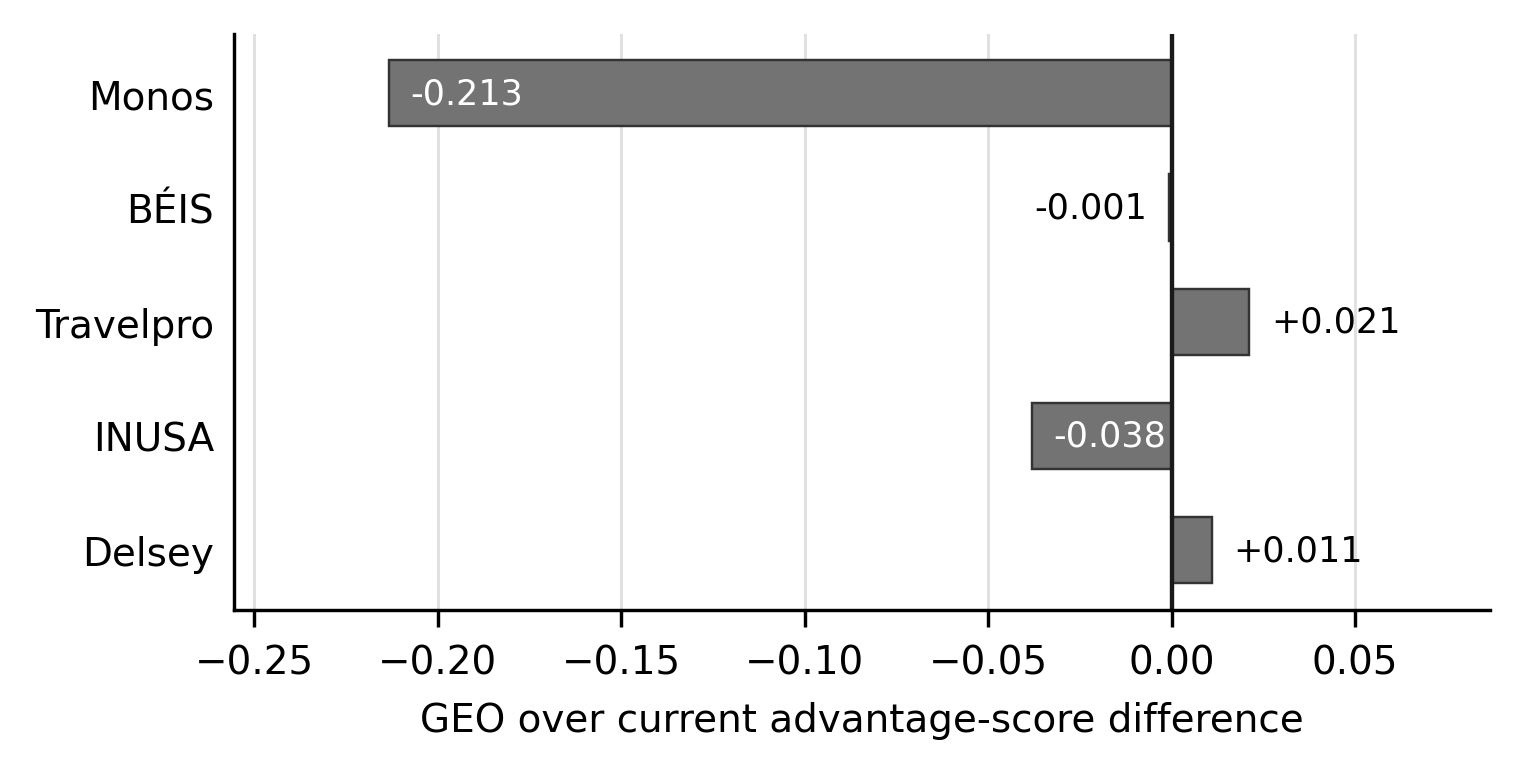

In [40]:
bar_df = summary.dropna(subset=["geo_over_current"]).copy()
bar_df["order"] = bar_df["product"].map({p: i for i, p in enumerate(PRODUCT_ORDER)}).fillna(999)
bar_df = bar_df.sort_values("order")

vals = bar_df["geo_over_current"].to_numpy(float)
products = bar_df["product"].tolist()
ypos = np.arange(len(bar_df))

fig, ax = plt.subplots(figsize=mm_to_inch(120, 58))

# Publication-style neutral bars
bars = ax.barh(
    ypos,
    vals,
    color="0.45",
    edgecolor="0.20",
    linewidth=0.5,
    height=0.58,
)

# Zero reference line
ax.axvline(0, color="0.10", linewidth=0.9)

# Y axis
ax.set_yticks(ypos)
ax.set_yticklabels(products, fontsize=8)
ax.invert_yaxis()

# X axis
ax.set_xlabel("GEO over current advantage-score difference", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", length=0, pad=4)

# Symmetric-ish x limits with enough room for text labels
xmin = min(np.nanmin(vals), 0)
xmax = max(np.nanmax(vals), 0)
span = max(xmax - xmin, 0.08)

ax.set_xlim(xmin - 0.18 * span, xmax + 0.28 * span)

# Light grid only on x axis
ax.grid(axis="x", color="0.88", linewidth=0.6)
ax.set_axisbelow(True)

# Numeric labels: large bars inside, small bars outside
offset = 0.025 * span
inside_threshold = 0.12 * span

for y, val in zip(ypos, vals):
    label = f"{val:+.3f}"

    if abs(val) >= inside_threshold:
        # Put label inside the bar to avoid overlapping y-axis labels
        if val < 0:
            x_text = val + offset
            ha = "left"
        else:
            x_text = val - offset
            ha = "right"
        color = "white"
    else:
        # Put small values just outside the bar
        if val < 0:
            x_text = val - offset
            ha = "right"
        else:
            x_text = val + offset
            ha = "left"
        color = "black"

    ax.text(
        x_text,
        y,
        label,
        va="center",
        ha=ha,
        fontsize=7.2,
        color=color,
        clip_on=False,
    )

# Clean frame
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_linewidth(0.7)
ax.spines["bottom"].set_linewidth(0.7)

# More left margin so product names never collide
fig.subplots_adjust(
    left=0.20,
    right=0.96,
    top=0.96,
    bottom=0.24,
)

save_pdf_png(fig, FIG_SUPP_DIR / "figureS2_geo_vs_current_bar")

## Notes for interpretation

The saved figure names remain unchanged, so Overleaf figure paths do not need to change. The only substantive update is Supplementary Figure S1: when the updated Comparison 01/02/03 CSVs contain provider-style answer metrics, the heatmap includes them next to the original citation/feature/PAIS metrics.

Recommended manuscript update: revise the Figure S1 caption to mention provider-style answer metrics, especially brand mention rate, citation/mention share of voice, first mention, and answer-position improvement. Source/domain share should stay in the limitations because the current answer files use controlled product-label citations rather than external URLs/domains.
